# Notebook 06: Insights & Strategy
Segment profiles, Pareto analysis, revenue at risk, segment-specific strategies.

Top 20% of customers (867) contribute 74.7% of revenue (Pareto)
Total customers: 4,338, Total revenue: £8,887,209


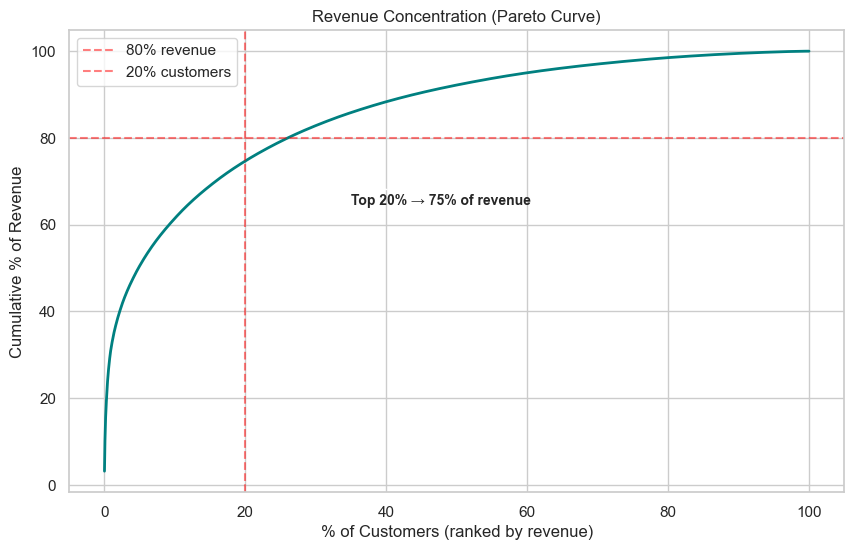

In [1]:
import os
import sys
import pandas as pd
import numpy as np

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

from src.visualizations import plot_pareto_curve

rfm = pd.read_csv('data/featured/customer_rfm.csv')
segment_profiles = pd.read_csv('data/featured/segment_profiles.csv')
cohort_retention = pd.read_csv('data/featured/cohort_retention.csv', index_col=0)

# Pareto: % revenue from top 20% of customers
rfm_sorted = rfm.sort_values('monetary', ascending=False).reset_index(drop=True)
rfm_sorted['cum_revenue'] = rfm_sorted['monetary'].cumsum()
total_rev = rfm_sorted['monetary'].sum()
rfm_sorted['cum_pct'] = rfm_sorted['cum_revenue'] / total_rev * 100
n_20pct = max(1, int(len(rfm_sorted) * 0.2))
revenue_top20 = rfm_sorted.iloc[:n_20pct]['monetary'].sum()
print(f"Top 20% of customers ({n_20pct}) contribute {revenue_top20/total_rev*100:.1f}% of revenue (Pareto)")
print(f"Total customers: {len(rfm):,}, Total revenue: £{total_rev:,.0f}")

# Visual Pareto curve
plot_pareto_curve(rfm, save_path='images/eda_charts/pareto_curve.png')

In [2]:
# Revenue at risk (At Risk + Can't Lose Them)
at_risk_segments = ['At Risk', "Can't Lose Them"]
profile_subset = segment_profiles[segment_profiles['segment'].isin(at_risk_segments)]
customers_at_risk = profile_subset['customer_count'].sum()
revenue_at_risk = profile_subset['total_revenue'].sum()
print(f"Revenue at risk (At Risk + Can't Lose Them): £{revenue_at_risk:,.0f}")
print(f"Customers in at-risk segments: {customers_at_risk:,}")

# Simple financial impact model
reactivation_rate = 0.15
avg_spend_at_risk = profile_subset['avg_monetary'].mean()
reactivated_customers = int(customers_at_risk * reactivation_rate)
est_reactivation_revenue = reactivated_customers * avg_spend_at_risk
print(f"If {reactivation_rate*100:.0f}% reactivated at avg £{avg_spend_at_risk:,.0f} → ~£{est_reactivation_revenue:,.0f} recovered revenue")

Revenue at risk (At Risk + Can't Lose Them): £1,407,925
Customers in at-risk segments: 1,324
If 15% reactivated at avg £1,030 → ~£204,023 recovered revenue


In [3]:
# Retention improvement model using cohort KPIs
month1 = cohort_retention.get('1', cohort_retention.iloc[:, 1]).mean()
month3 = cohort_retention.get('3', cohort_retention.iloc[:, 3]).mean() if cohort_retention.shape[1] > 3 else np.nan
month6 = cohort_retention.get('6', cohort_retention.iloc[:, 6]).mean() if cohort_retention.shape[1] > 6 else np.nan

print(f"Average Month-1 retention: {month1:.1f}%")
if not np.isnan(month3):
    print(f"Average Month-3 retention: {month3:.1f}%")
if not np.isnan(month6):
    print(f"Average Month-6 retention: {month6:.1f}%")

# Hypothetical uplift: improve Month-1 retention from current to 35%
current_rate = month1 / 100
target_rate = 0.35

new_customers = segment_profiles.loc[segment_profiles['segment'] == 'New Customers', 'customer_count'].values
avg_monetary_new = segment_profiles.loc[segment_profiles['segment'] == 'New Customers', 'avg_monetary'].values

if len(new_customers) and len(avg_monetary_new):
    base_returns = new_customers[0] * current_rate
    target_returns = new_customers[0] * target_rate
    incremental_customers = max(0, target_returns - base_returns)
    incremental_revenue = incremental_customers * avg_monetary_new[0]
    print(f"If Month-1 retention improves from {month1:.1f}% to 35%, ~{incremental_customers:,.0f} extra customers retained")
    print(f"Incremental revenue from better onboarding: ~£{incremental_revenue:,.0f}")

Average Month-1 retention: 20.6%
Average Month-3 retention: 23.2%
Average Month-6 retention: 24.4%
If Month-1 retention improves from 20.6% to 35%, ~34 extra customers retained
Incremental revenue from better onboarding: ~£41,268


## Segment strategies tied to numbers

Run the cells above first to print the exact KPIs (Month-1 retention, customers at risk, revenue at risk, and estimated reactivation revenue). Then interpret them with these strategies:

- **Champions**: high avg monetary and low recency. Even a 10–15% lift in their avg spend (via VIP offers) translates directly into sizeable incremental revenue.
- **Loyal Customers**: large base with strong revenue share — upsell and cross-sell can shift their avg monetary closer to Champions.
- **New Customers**: onboarding experiments that lift Month-1 retention toward the target (e.g., 35%) drive the incremental revenue estimated in the retention model.
- **At Risk + Can't Lose Them**: focus of the win-back program — the customers and revenue at risk reported above anchor the reactivation business case.
- **Lost / Hibernating**: deprioritize heavy spend; use low-cost automated touches, and reallocate budget toward high-ROI segments.